# Compare YOLO26 Fine-tuning Versions (v1 vs v2 vs v3)

Este notebook agrega os resultados das 3 versões de fine-tuning do YOLO26 no
ISIC 2018 Task 1 (`compare_models_v1`, `v2`, `v3`) num único conjunto de
gráficos para facilitar a comparação direta entre versões e tamanhos de modelo.

**Fontes de dados**: `results.csv` de cada experimento de cada versão. As
três versões diferem em hiperparâmetros (config antiga / config refinada /
config refinada + ajustes de ISIC) — este notebook não interpreta os deltas;
apenas os exibe.

## 1. Setup and Path Configuration

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from IPython.display import display

# Estilo dos plots (consistente com os notebooks v1/v2/v3)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 300

# ================= PATH CONFIGURATION =================
unb_server = True

if unb_server:
    BASE_DIR = Path("/home/antoniovinicius/projects/sandbox_yolo26")
else:
    BASE_DIR = Path("/home/avmoura_linux/Documents/unb/sandbox_yolo26")

# Cada versão tem um LOG_DIR e um padrão de nome de pasta diferente.
# Mantemos a mesma convenção dos notebooks v1/v2/v3 originais.
VERSIONS = {
    "RGB": {
        "log_dir": BASE_DIR / "logs",
        "model_dirs": {
            "Small":  "yolo26_small_ft_isic_2018_v5"
        },
    },
    "LAB": {
        "log_dir": BASE_DIR / "logs",
        "model_dirs": {
            "Small":  "yolo26_small_ft_isic_2018_v5_lab"
        },
    }
}

MODEL_ORDER = ["Small"]
VERSION_ORDER = ["RGB", "LAB"]

# Paleta dedicada para versões (consistente em todos os gráficos)
VERSION_PALETTE = {
    "RGB": "#3182bd",  # azul médio
    "LAB": "#08519c",  # azul escuro
}

print("Setup OK")

Setup OK


## 2. Data Extraction (loop over versions × models)

In [12]:
def extract_summary(version, model_name, df):
    """Extrai métricas-resumo da melhor época (mask mAP@50-95)."""
    df = df.copy()
    df.columns = df.columns.str.strip()
    best_idx = df['metrics/mAP50-95(M)'].idxmax()
    best = df.iloc[best_idx]
    total_time_min = float(df['time'].max()) / 60.0
    return {
        'Version': version,
        'Model': model_name,
        'Best Epoch': int(best['epoch']),
        'Total Epochs': int(df['epoch'].max()),
        'Mask mAP@50': float(best['metrics/mAP50(M)']),
        'Mask mAP@50-95': float(best['metrics/mAP50-95(M)']),
        'BBox mAP@50': float(best['metrics/mAP50(B)']),
        'BBox mAP@50-95': float(best['metrics/mAP50-95(B)']),
        'Mask Precision': float(best['metrics/precision(M)']),
        'Mask Recall': float(best['metrics/recall(M)']),
        'Val Mask Loss': float(best['val/seg_loss']),
        'Train Time (min)': total_time_min,
    }


summary_rows = []
curves = {}  # curves[version][model_name] = DataFrame com a curva completa

for version, conf in VERSIONS.items():
    log_dir = conf["log_dir"]
    curves[version] = {}
    for model_name in MODEL_ORDER:
        dir_name = conf["model_dirs"].get(model_name)
        if dir_name is None:
            continue
        csv_path = log_dir / dir_name / "results.csv"
        if not csv_path.exists():
            print(f"⚠ Missing: [{version}] {model_name} -> {csv_path}")
            continue
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        curves[version][model_name] = df
        summary_rows.append(extract_summary(version, model_name, df))

df_long = pd.DataFrame(summary_rows)
df_long['Model'] = pd.Categorical(df_long['Model'], categories=MODEL_ORDER, ordered=True)
df_long['Version'] = pd.Categorical(df_long['Version'], categories=VERSION_ORDER, ordered=True)
df_long = df_long.sort_values(['Model', 'Version']).reset_index(drop=True)

display(df_long.round({
    'Mask mAP@50': 4, 'Mask mAP@50-95': 4,
    'BBox mAP@50': 4, 'BBox mAP@50-95': 4,
    'Mask Precision': 4, 'Mask Recall': 4,
    'Val Mask Loss': 4, 'Train Time (min)': 2,
}))

,Version,Model,Best Epoch,Total Epochs,Mask mAP@50,Mask mAP@50-95,BBox mAP@50,BBox mAP@50-95,Mask Precision,Mask Recall,Val Mask Loss,Train Time (min)
0,RGB,Small,32,52,0.9661,0.7021,0.9769,0.6718,0.9272,0.95,1.5349,20.68
1,LAB,Small,12,28,0.9241,0.6464,0.9408,0.5478,0.8624,0.86,1.6721,11.20


## 3. Performance Comparison Across Versions

### 3.1 Mask mAP — agrupado por modelo, hue=versão

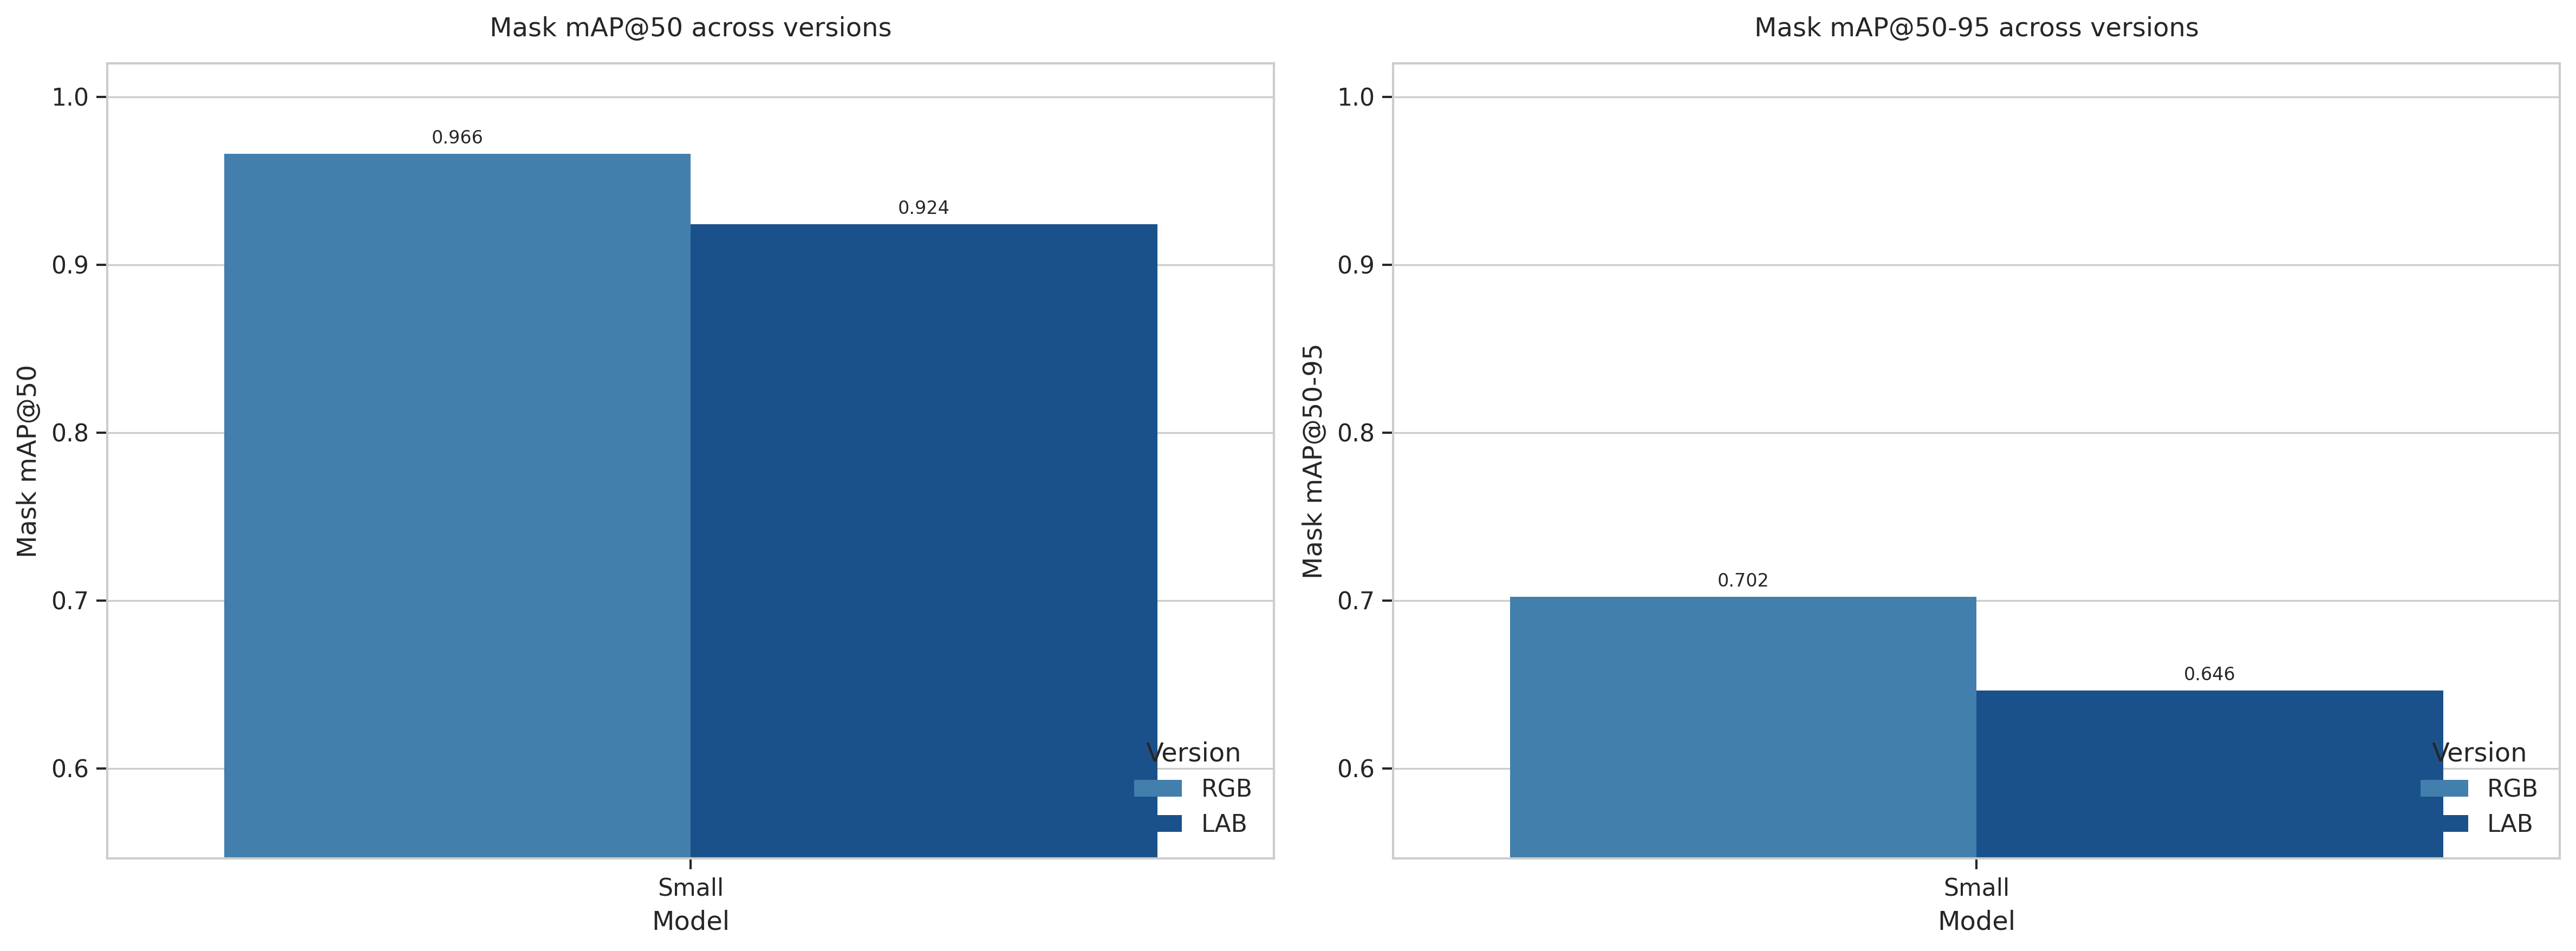

In [13]:
def add_value_labels(ax, fmt='{:.3f}'):
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2., h),
                        ha='center', va='bottom',
                        xytext=(0, 3), textcoords='offset points',
                        fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y_min_mask = max(0.0, df_long['Mask mAP@50-95'].min() - 0.1)
y_min_bbox = max(0.0, df_long['BBox mAP@50-95'].min() - 0.1)

# Mask mAP@50
sns.barplot(data=df_long, x='Model', y='Mask mAP@50', hue='Version',
            order=MODEL_ORDER, hue_order=VERSION_ORDER,
            palette=VERSION_PALETTE, ax=axes[0])
axes[0].set_title('Mask mAP@50 across versions', pad=12)
axes[0].set_ylim(y_min_mask, 1.02)
axes[0].set_ylabel('Mask mAP@50')
axes[0].legend(title='Version', loc='lower right')
add_value_labels(axes[0])

# Mask mAP@50-95
sns.barplot(data=df_long, x='Model', y='Mask mAP@50-95', hue='Version',
            order=MODEL_ORDER, hue_order=VERSION_ORDER,
            palette=VERSION_PALETTE, ax=axes[1])
axes[1].set_title('Mask mAP@50-95 across versions', pad=12)
axes[1].set_ylim(y_min_mask, 1.02)
axes[1].set_ylabel('Mask mAP@50-95')
axes[1].legend(title='Version', loc='lower right')
add_value_labels(axes[1])

plt.tight_layout()
plt.show()

### 3.2 BBox mAP — agrupado por modelo, hue=versão

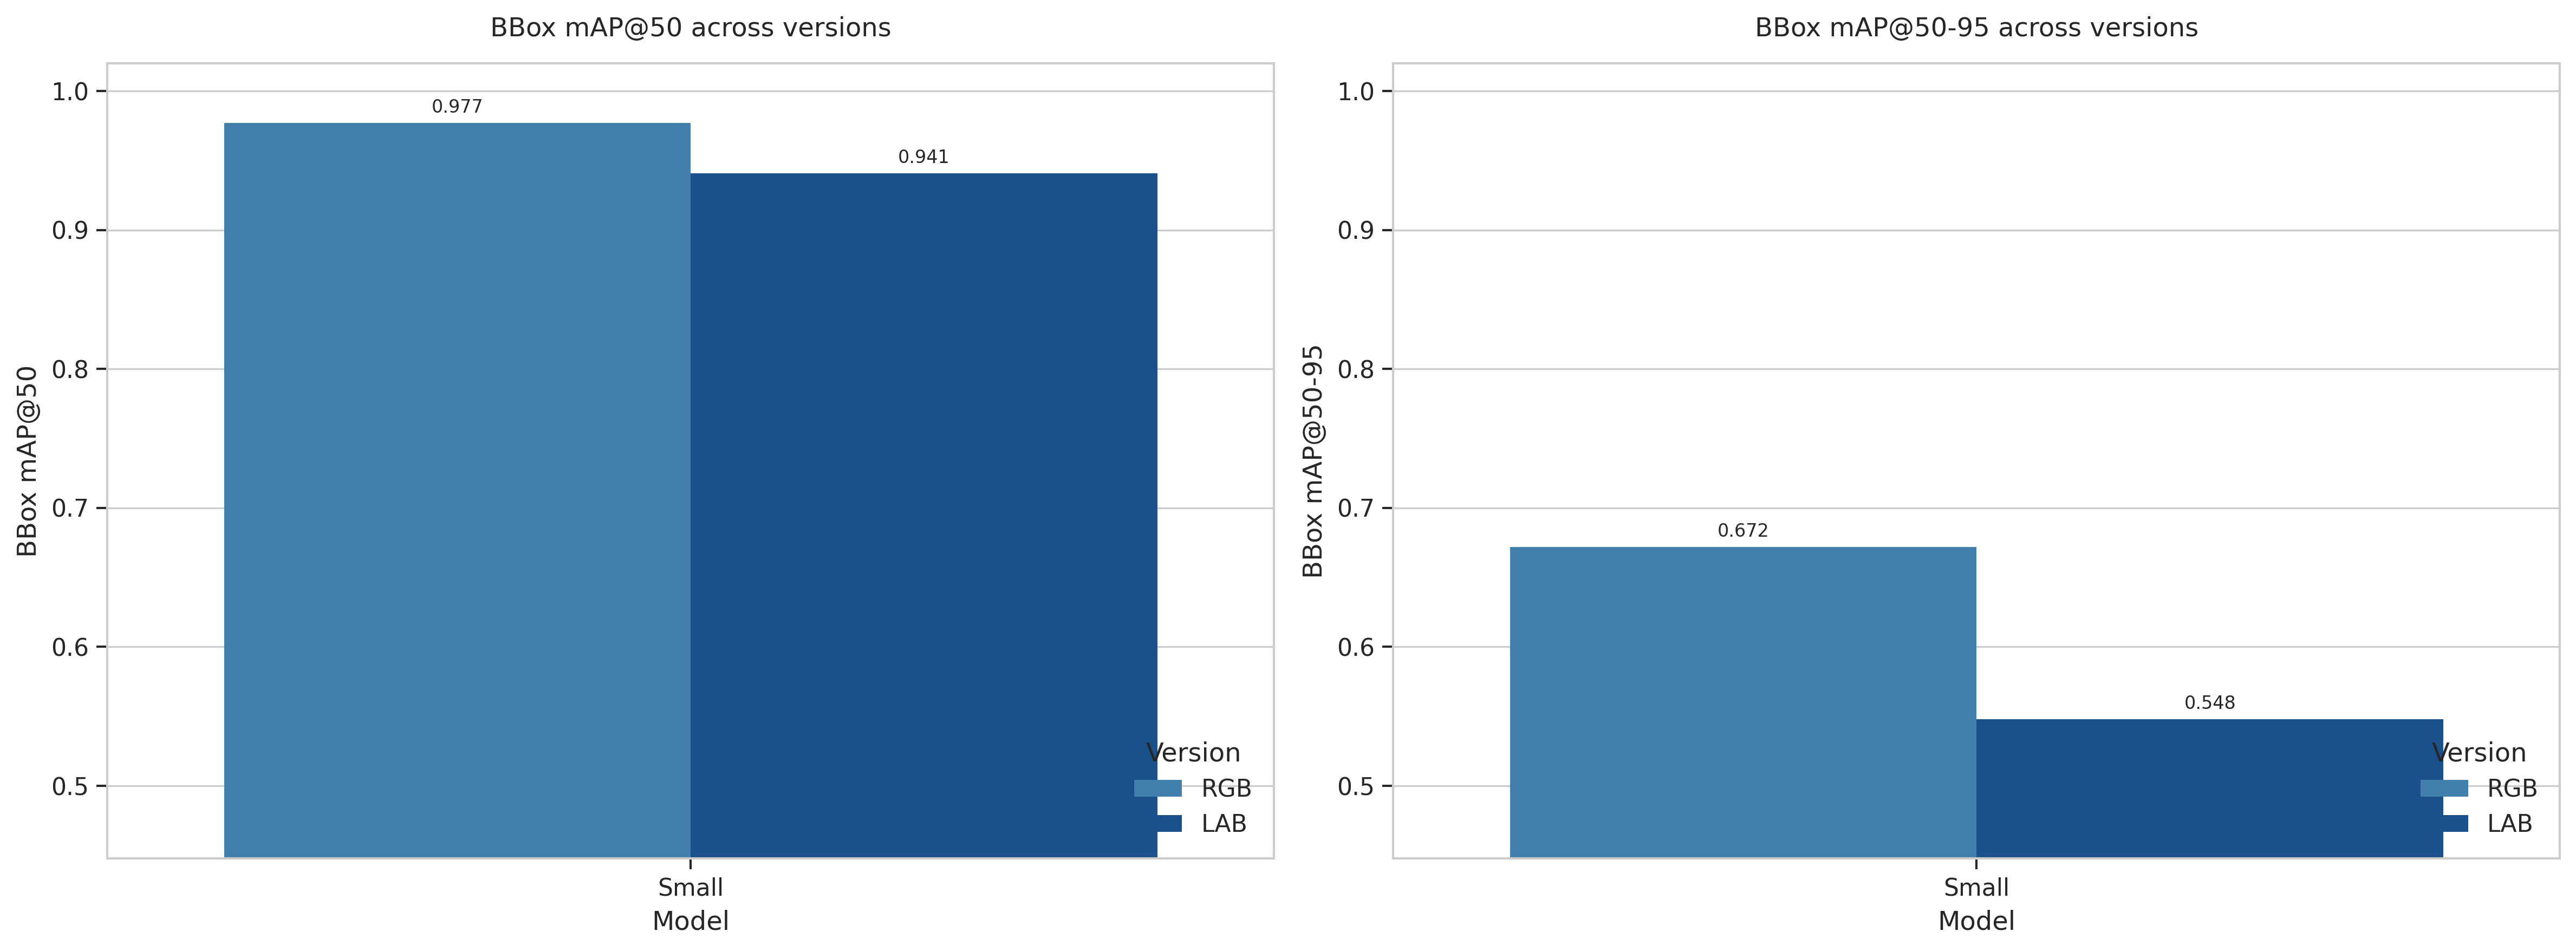

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BBox mAP@50
sns.barplot(data=df_long, x='Model', y='BBox mAP@50', hue='Version',
            order=MODEL_ORDER, hue_order=VERSION_ORDER,
            palette=VERSION_PALETTE, ax=axes[0])
axes[0].set_title('BBox mAP@50 across versions', pad=12)
axes[0].set_ylim(y_min_bbox, 1.02)
axes[0].set_ylabel('BBox mAP@50')
axes[0].legend(title='Version', loc='lower right')
add_value_labels(axes[0])

# BBox mAP@50-95
sns.barplot(data=df_long, x='Model', y='BBox mAP@50-95', hue='Version',
            order=MODEL_ORDER, hue_order=VERSION_ORDER,
            palette=VERSION_PALETTE, ax=axes[1])
axes[1].set_title('BBox mAP@50-95 across versions', pad=12)
axes[1].set_ylim(y_min_bbox, 1.02)
axes[1].set_ylabel('BBox mAP@50-95')
axes[1].legend(title='Version', loc='lower right')
add_value_labels(axes[1])

plt.tight_layout()
plt.show()

### 3.3 Precision, Recall, Val Loss e Tempo de Treino

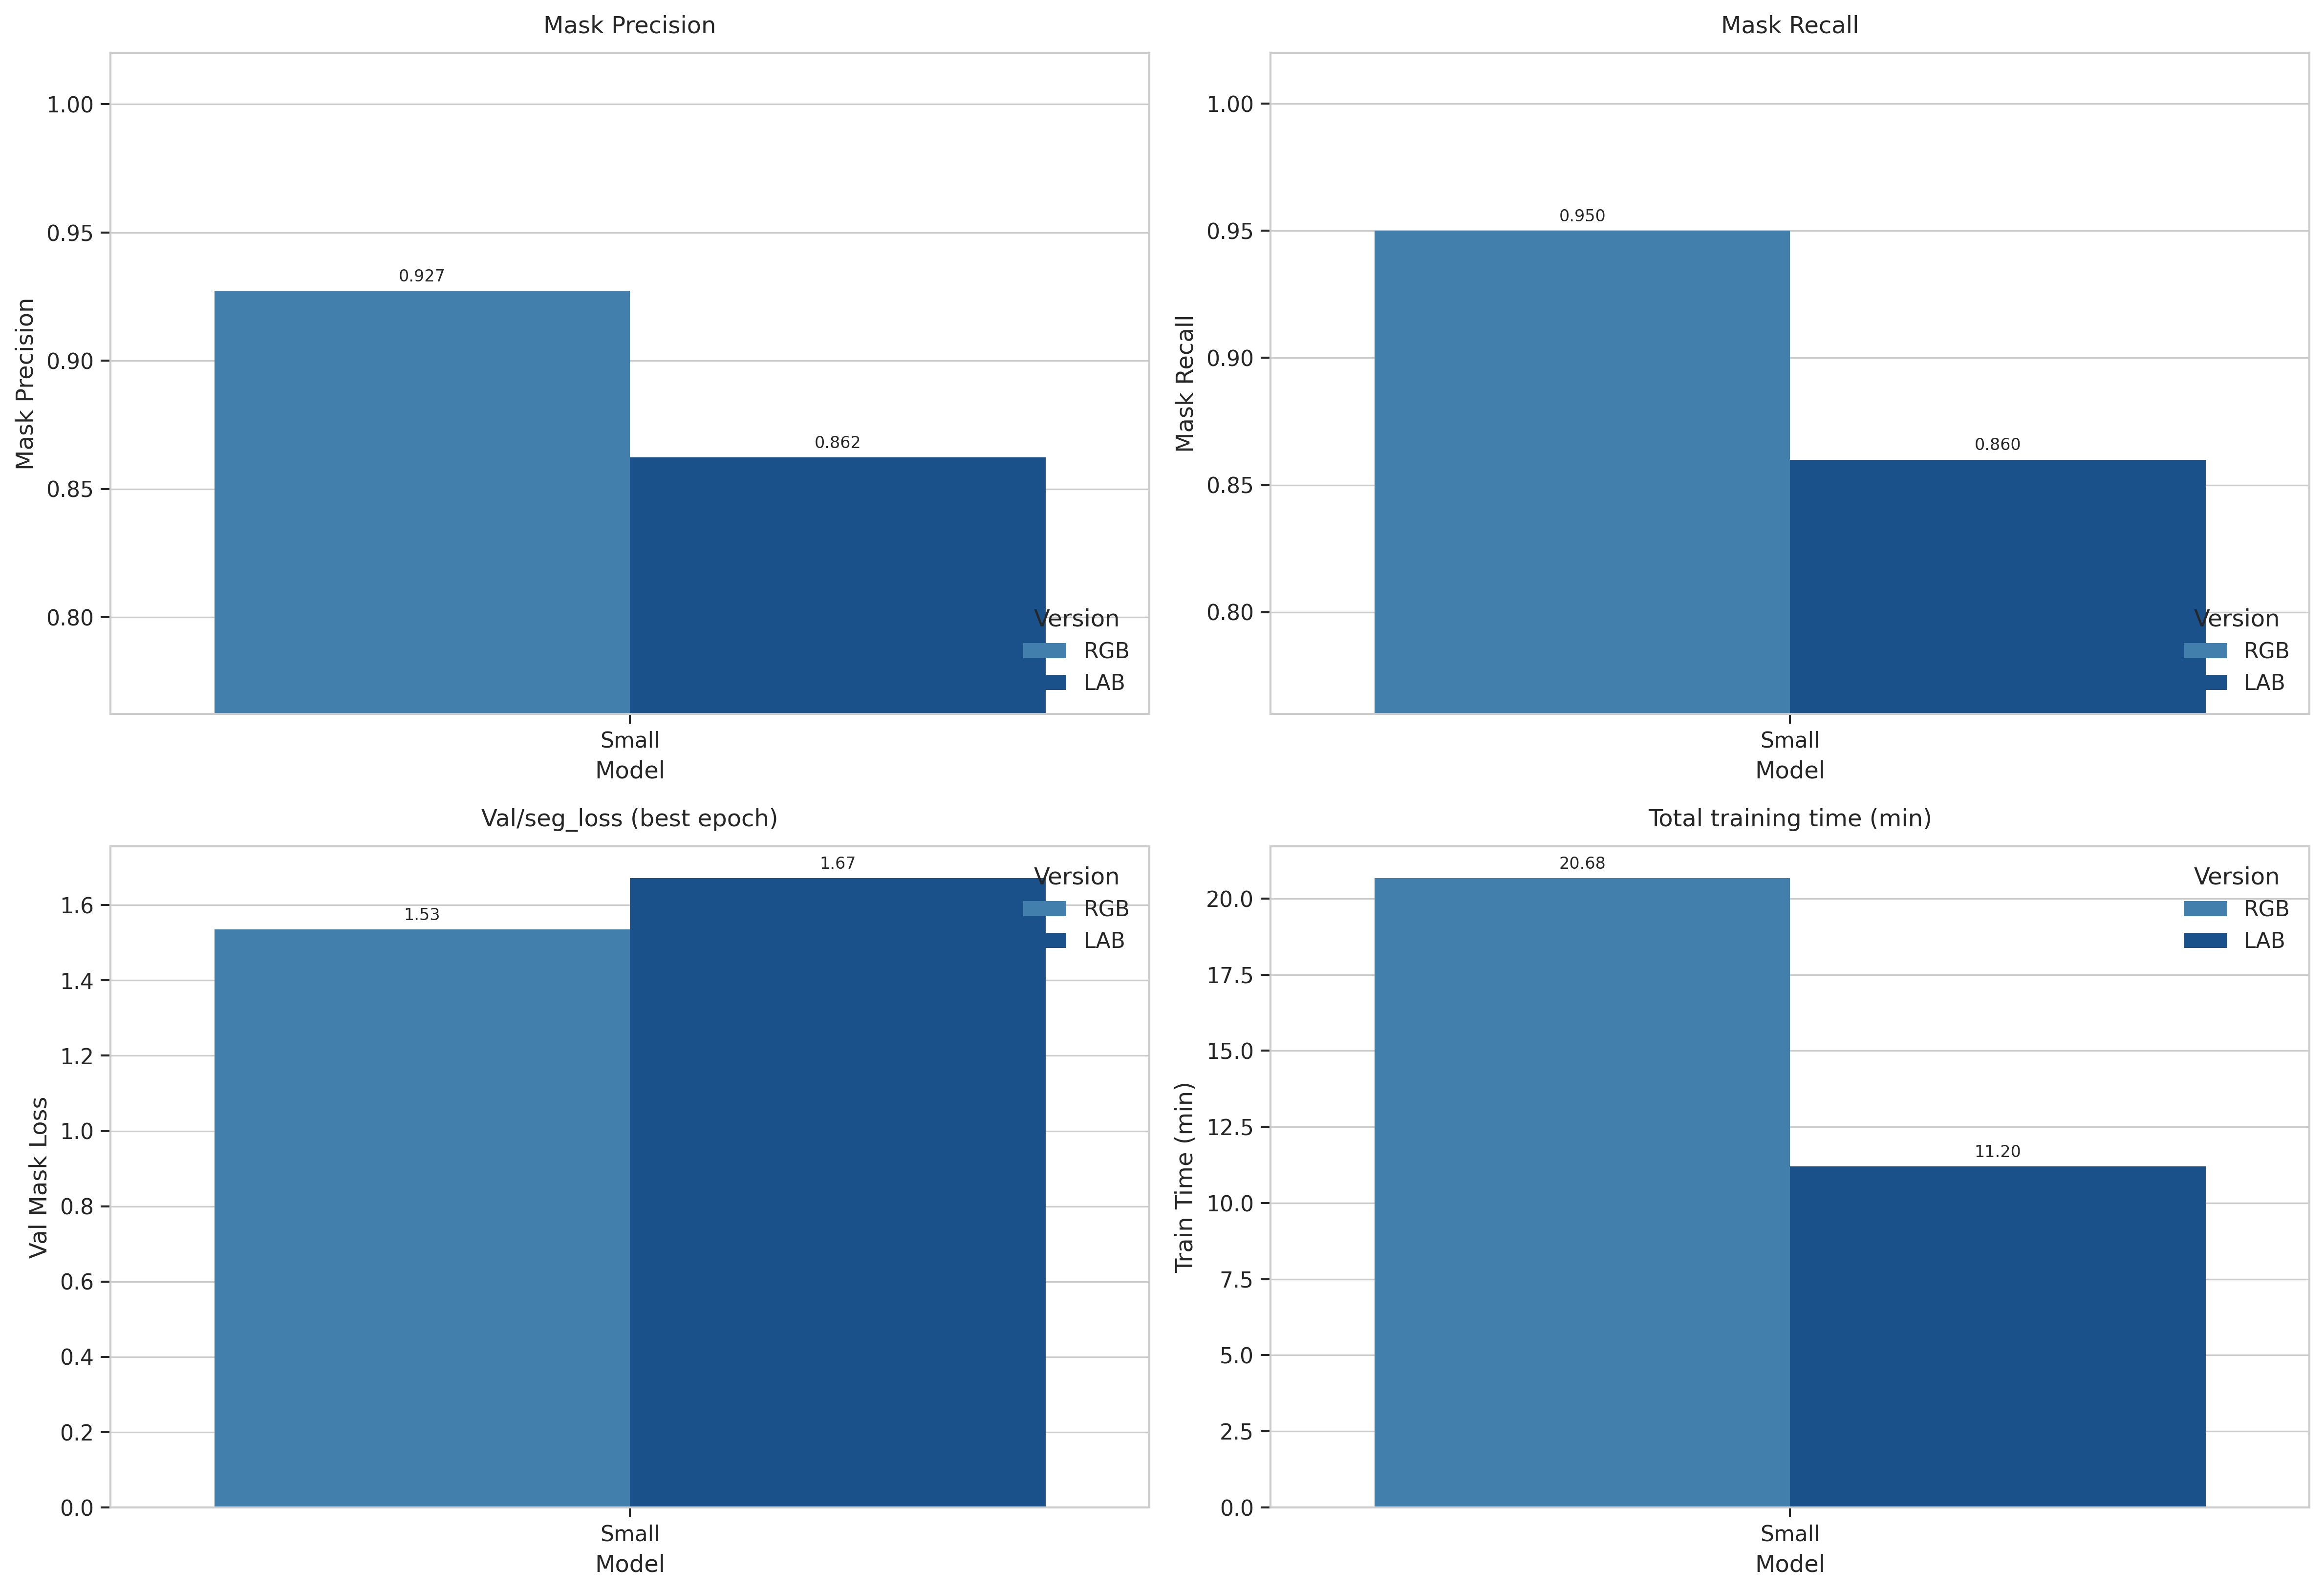

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

panels = [
    ('Mask Precision',     axes[0, 0], 'Mask Precision',     False),
    ('Mask Recall',        axes[0, 1], 'Mask Recall',        False),
    ('Val Mask Loss',      axes[1, 0], 'Val/seg_loss (best epoch)', True),
    ('Train Time (min)',   axes[1, 1], 'Total training time (min)', True),
]

for col, ax, title, is_loss_or_time in panels:
    sns.barplot(data=df_long, x='Model', y=col, hue='Version',
                order=MODEL_ORDER, hue_order=VERSION_ORDER,
                palette=VERSION_PALETTE, ax=ax)
    ax.set_title(title, pad=10)
    ax.legend(title='Version', loc='upper right' if is_loss_or_time else 'lower right')
    fmt = '{:.2f}' if is_loss_or_time else '{:.3f}'
    add_value_labels(ax, fmt=fmt)
    if not is_loss_or_time:
        ymin = max(0.0, df_long[col].min() - 0.1)
        ax.set_ylim(ymin, 1.02)

plt.tight_layout()
plt.show()

## 4. Robustez Geométrica (mAP50-95 / mAP50)

Mostra quanto da precisão de detecção/máscara é mantido sob IoU rigoroso. Quanto maior, melhor a fidelidade de borda.

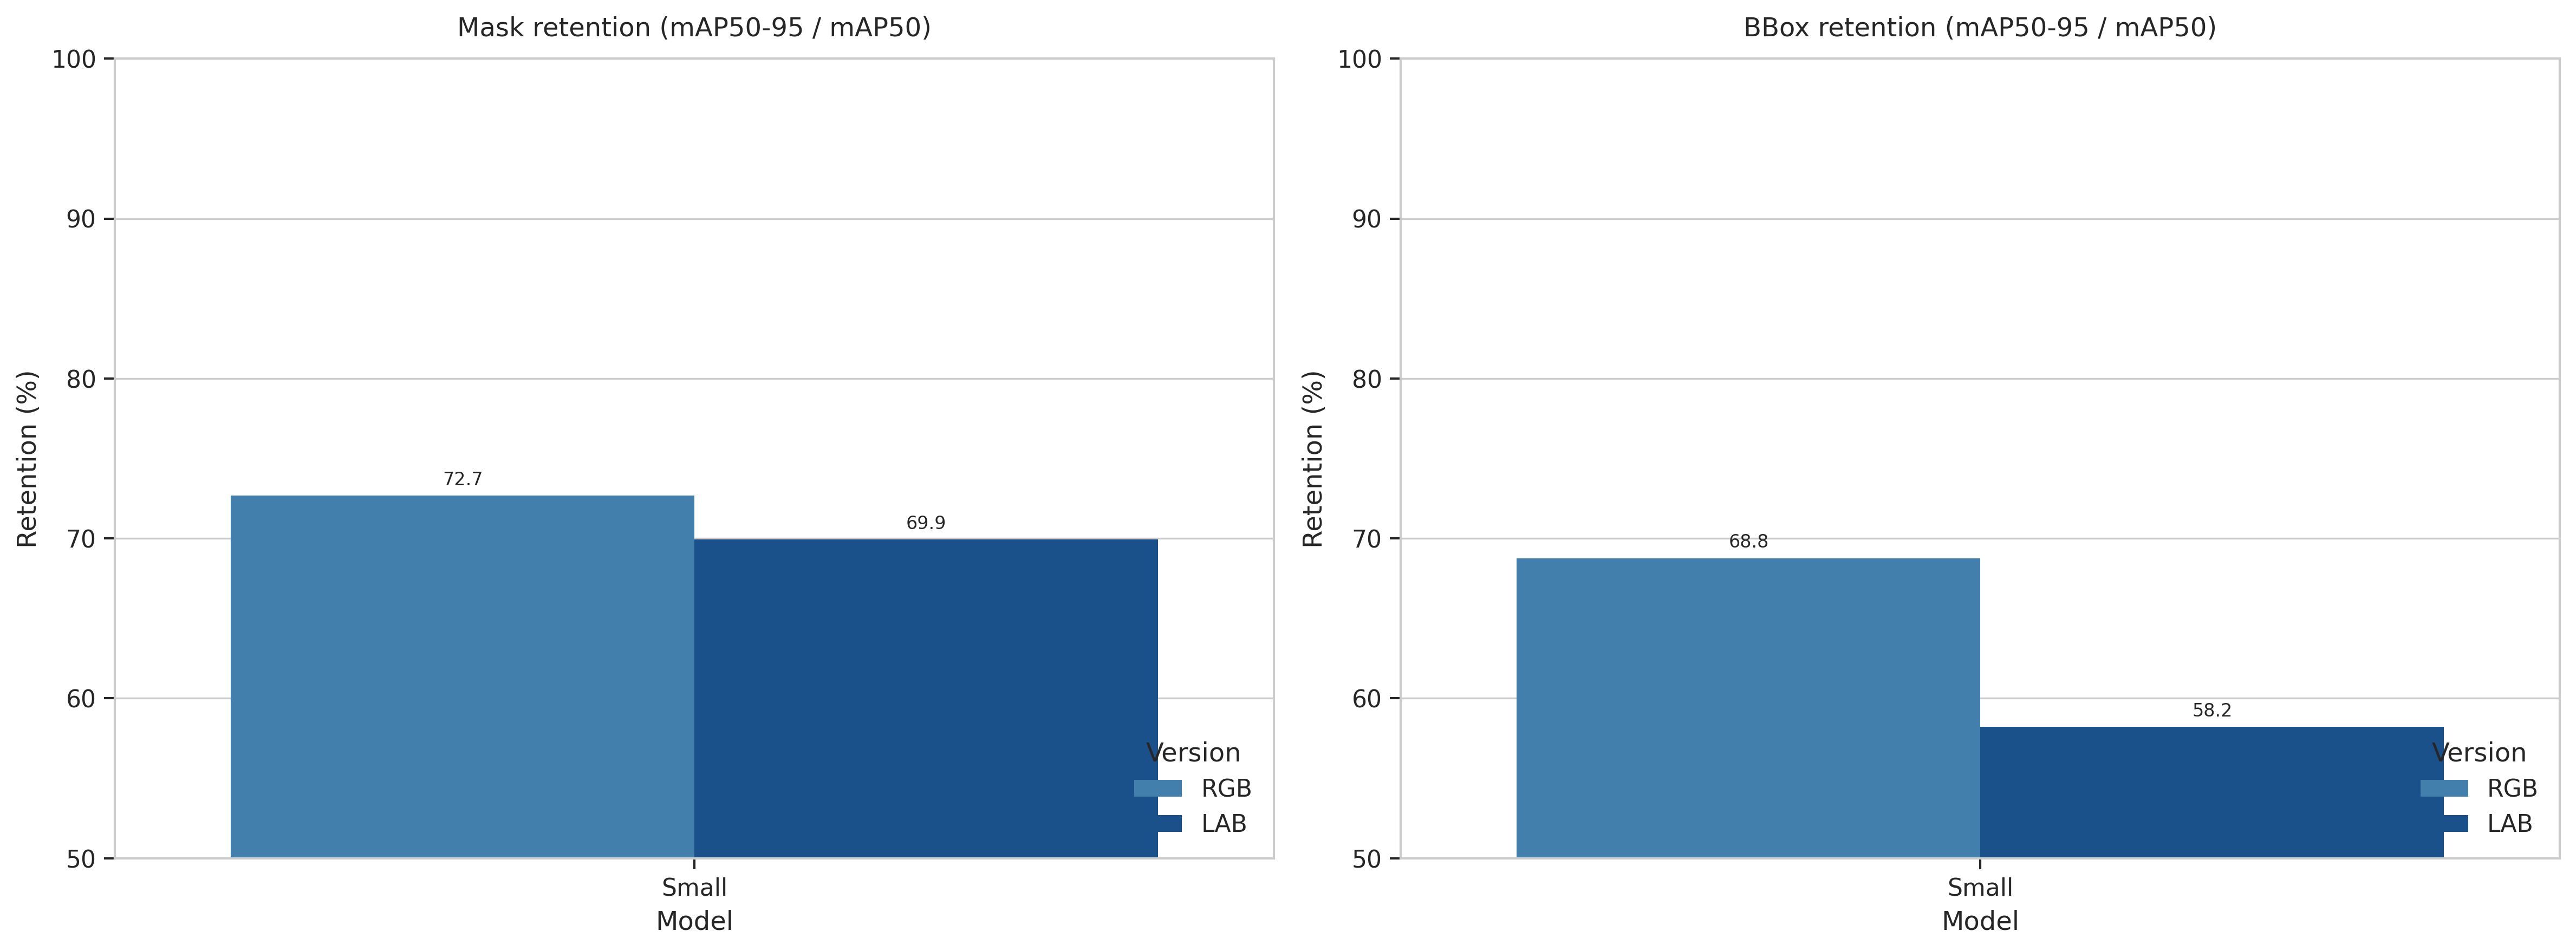

In [16]:
df_robust = df_long.copy()
df_robust['Mask Retention (%)'] = (df_robust['Mask mAP@50-95'] / df_robust['Mask mAP@50']) * 100
df_robust['BBox Retention (%)'] = (df_robust['BBox mAP@50-95'] / df_robust['BBox mAP@50']) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_robust, x='Model', y='Mask Retention (%)', hue='Version',
            order=MODEL_ORDER, hue_order=VERSION_ORDER,
            palette=VERSION_PALETTE, ax=axes[0])
axes[0].set_title('Mask retention (mAP50-95 / mAP50)', pad=10)
axes[0].set_ylim(50, 100)
axes[0].set_ylabel('Retention (%)')
axes[0].legend(title='Version', loc='lower right')
add_value_labels(axes[0], fmt='{:.1f}')

sns.barplot(data=df_robust, x='Model', y='BBox Retention (%)', hue='Version',
            order=MODEL_ORDER, hue_order=VERSION_ORDER,
            palette=VERSION_PALETTE, ax=axes[1])
axes[1].set_title('BBox retention (mAP50-95 / mAP50)', pad=10)
axes[1].set_ylim(50, 100)
axes[1].set_ylabel('Retention (%)')
axes[1].legend(title='Version', loc='lower right')
add_value_labels(axes[1], fmt='{:.1f}')

plt.tight_layout()
plt.show()

## 5. Curvas de Treino Suavizadas — uma figura por modelo, uma linha por versão

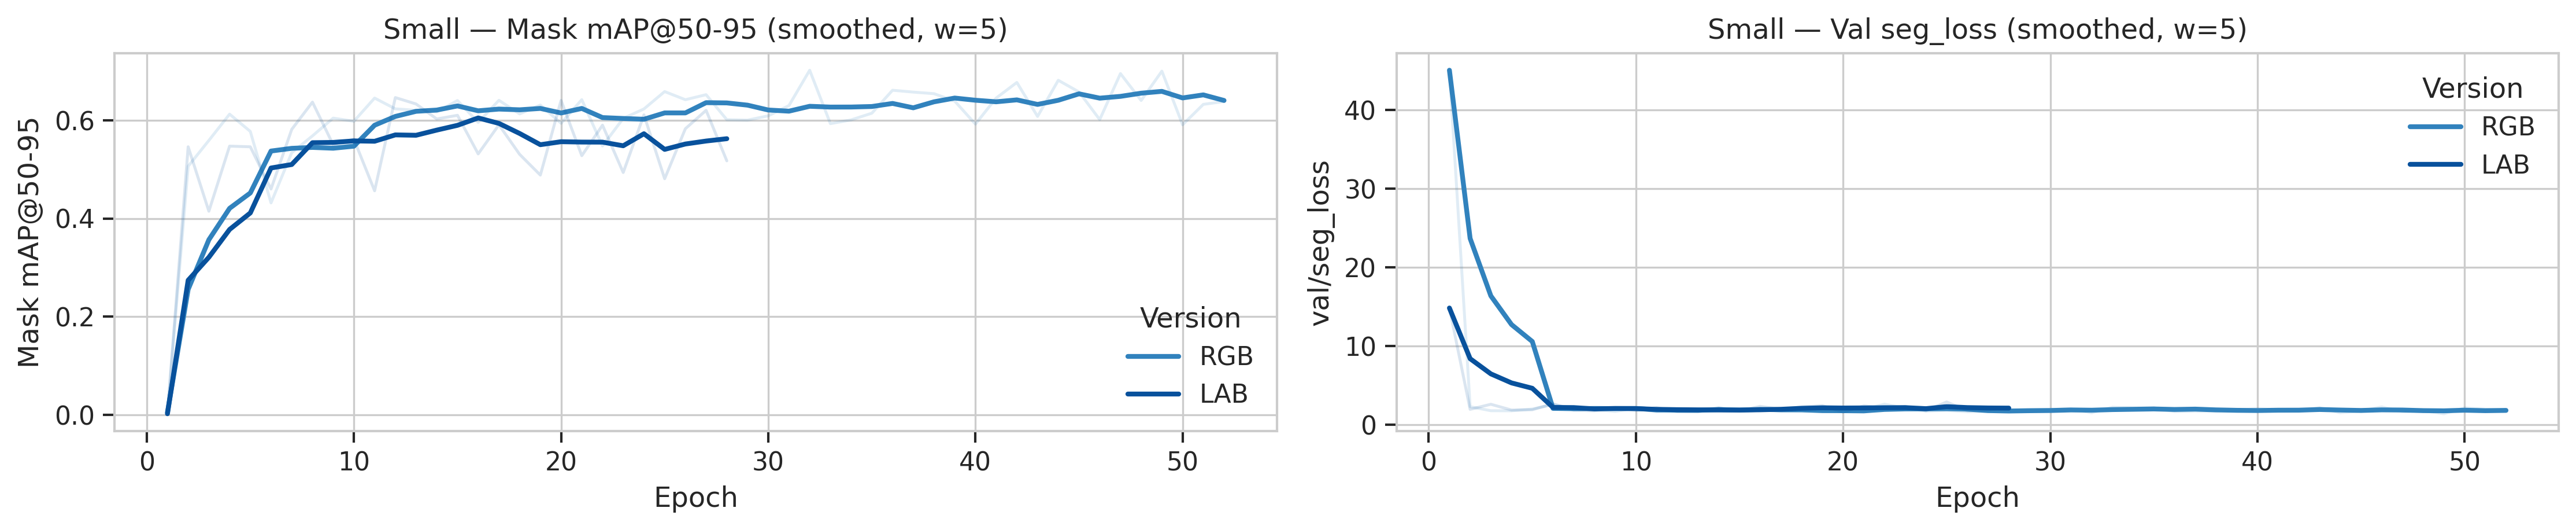

In [17]:
WINDOW = 5  # média móvel

# Layout: 5 modelos × 2 colunas (mAP50-95 vs val/seg_loss)
n_models = len(MODEL_ORDER)
fig, axes = plt.subplots(n_models, 2, figsize=(15, 3.2 * n_models), sharex=False)

if n_models == 1:
    axes = np.array([axes])

for i, model_name in enumerate(MODEL_ORDER):
    ax_map = axes[i, 0]
    ax_loss = axes[i, 1]

    for version in VERSION_ORDER:
        df = curves.get(version, {}).get(model_name)
        if df is None:
            continue
        color = VERSION_PALETTE[version]
        smoothed_map  = df['metrics/mAP50-95(M)'].rolling(window=WINDOW, min_periods=1).mean()
        smoothed_loss = df['val/seg_loss'].rolling(window=WINDOW, min_periods=1).mean()

        ax_map.plot(df['epoch'], df['metrics/mAP50-95(M)'], alpha=0.15, color=color)
        ax_map.plot(df['epoch'], smoothed_map, label=version, linewidth=2.0, color=color)

        ax_loss.plot(df['epoch'], df['val/seg_loss'], alpha=0.15, color=color)
        ax_loss.plot(df['epoch'], smoothed_loss, label=version, linewidth=2.0, color=color)

    ax_map.set_title(f'{model_name} — Mask mAP@50-95 (smoothed, w={WINDOW})')
    ax_map.set_xlabel('Epoch')
    ax_map.set_ylabel('Mask mAP@50-95')
    ax_map.legend(title='Version', loc='lower right')

    ax_loss.set_title(f'{model_name} — Val seg_loss (smoothed, w={WINDOW})')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('val/seg_loss')
    ax_loss.legend(title='Version', loc='upper right')

plt.tight_layout()
plt.show()

## 6. Velocidade de Convergência: épocas até atingir 95% do best

Mostra em que época cada run alcançou 95% do seu próprio best em `mask mAP@50-95`. Útil para comparar quão rápido cada versão converge.

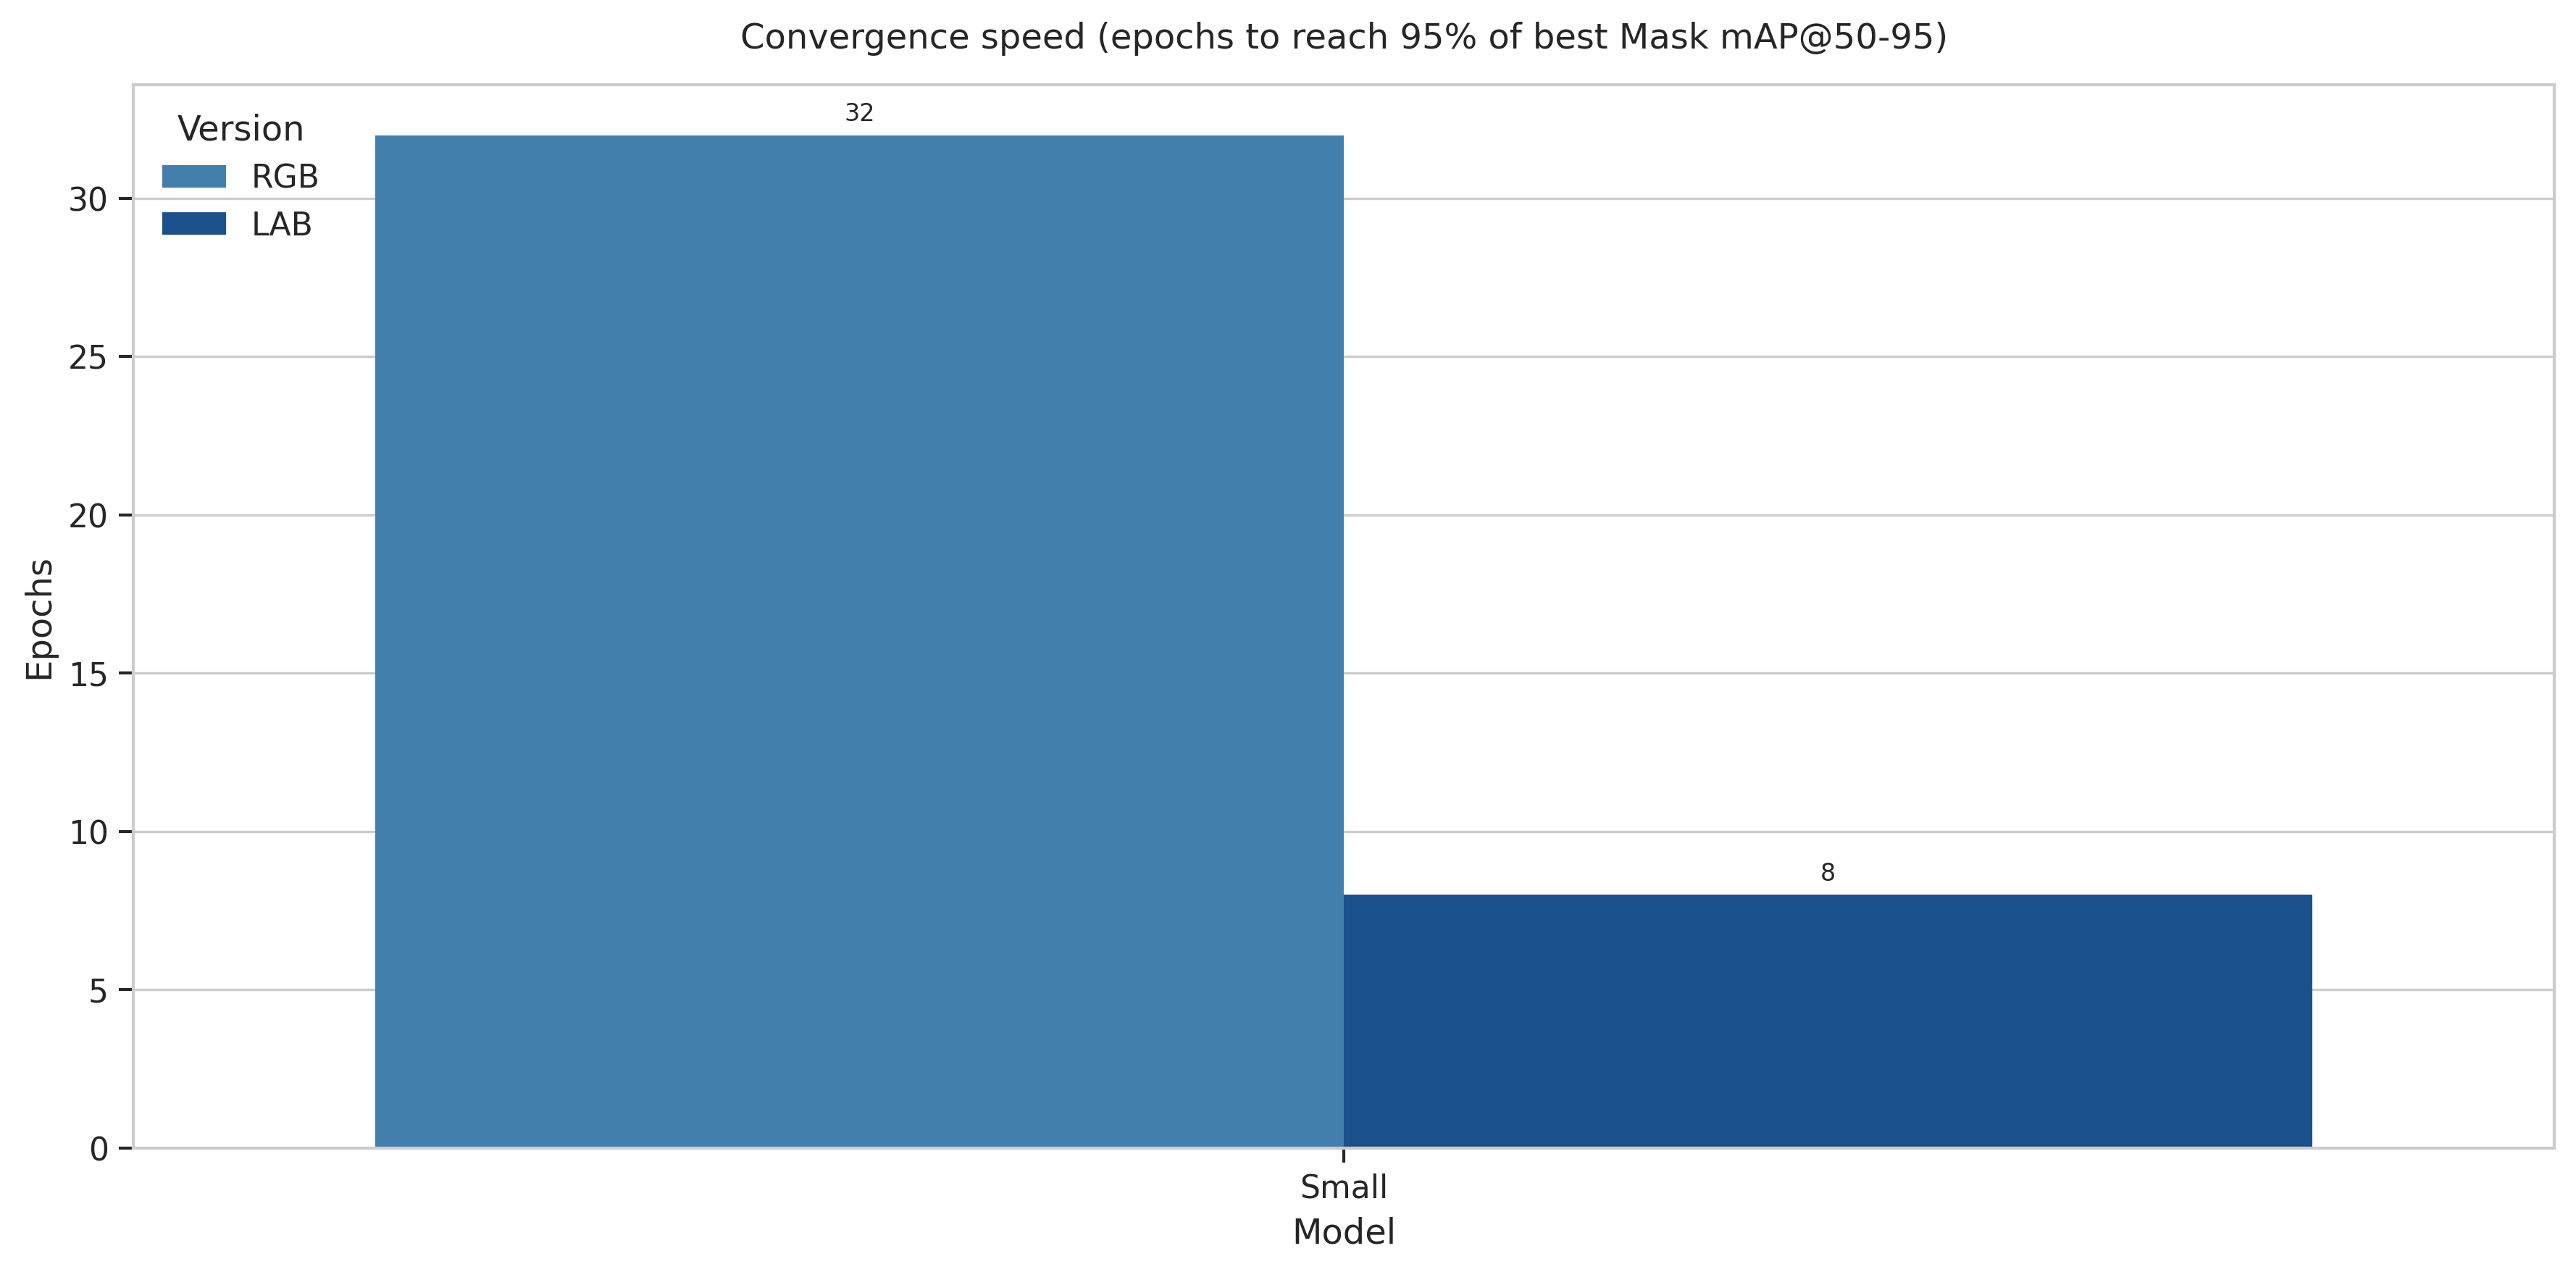

,Version,Model,Epochs to 95% of best
0,RGB,Small,32
1,LAB,Small,8


In [18]:
def epochs_to_threshold(df, target_col='metrics/mAP50-95(M)', frac=0.95):
    best = df[target_col].max()
    threshold = frac * best
    above = df[df[target_col] >= threshold]
    if len(above) == 0:
        return None
    return int(above['epoch'].iloc[0])


rows = []
for version, models in curves.items():
    for model_name, df in models.items():
        ep = epochs_to_threshold(df, 'metrics/mAP50-95(M)', 0.95)
        rows.append({'Version': version, 'Model': model_name,
                     'Epochs to 95% of best': ep})

df_speed = pd.DataFrame(rows)
df_speed['Model']   = pd.Categorical(df_speed['Model'],   categories=MODEL_ORDER,   ordered=True)
df_speed['Version'] = pd.Categorical(df_speed['Version'], categories=VERSION_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_speed, x='Model', y='Epochs to 95% of best', hue='Version',
            order=MODEL_ORDER, hue_order=VERSION_ORDER,
            palette=VERSION_PALETTE, ax=ax)
ax.set_title('Convergence speed (epochs to reach 95% of best Mask mAP@50-95)', pad=12)
ax.set_ylabel('Epochs')
ax.legend(title='Version', loc='upper left')
add_value_labels(ax, fmt='{:.0f}')
plt.tight_layout()
plt.show()

display(df_speed)

## 7. Tabela-Resumo: Δ entre versões

Diferenças absolutas em `Mask mAP@50-95` por modelo: v2−v1, v3−v1, v3−v2.

In [19]:
pivot = df_long.pivot_table(
    index='Model', columns='Version', values='Mask mAP@50-95',
    observed=True,
)
pivot = pivot.reindex(MODEL_ORDER)

deltas = pd.DataFrame(index=pivot.index)
if {'v1', 'v2'}.issubset(pivot.columns):
    deltas['Δ v2 − v1'] = pivot['v2'] - pivot['v1']
if {'v1', 'v3'}.issubset(pivot.columns):
    deltas['Δ v3 − v1'] = pivot['v3'] - pivot['v1']
if {'v2', 'v3'}.issubset(pivot.columns):
    deltas['Δ v3 − v2'] = pivot['v3'] - pivot['v2']

result = pd.concat([pivot.round(4), deltas.round(4)], axis=1)
display(result)

,RGB,LAB
Model,,
Small,0.7021,0.6464


## 8. Heatmap geral — todas as métricas, todos os modelos, todas as versões

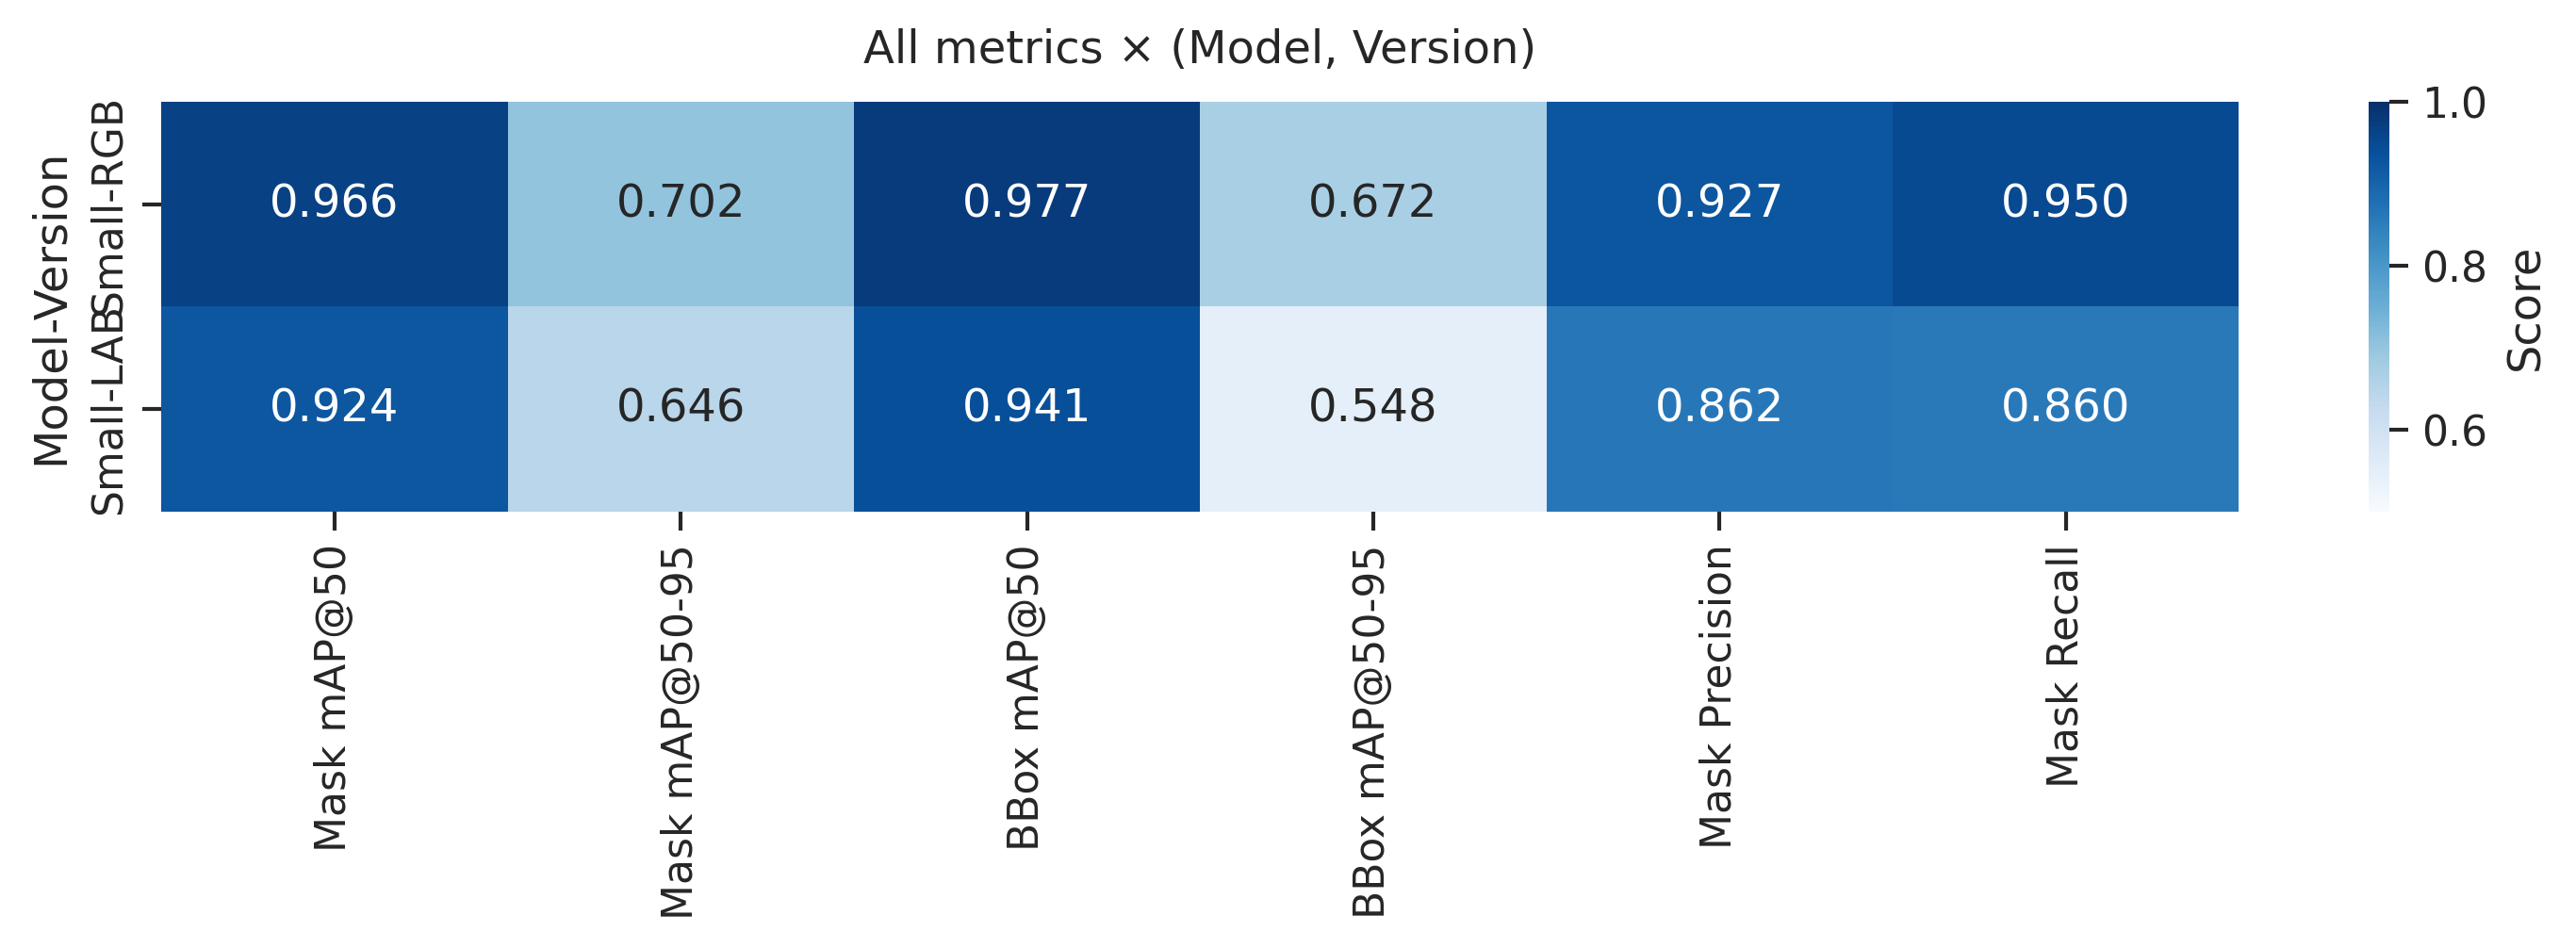

In [20]:
metrics_cols = ['Mask mAP@50', 'Mask mAP@50-95',
                'BBox mAP@50', 'BBox mAP@50-95',
                'Mask Precision', 'Mask Recall']

# Reorganizar como matriz: linhas = (Model, Version), colunas = métricas
df_heat = df_long.set_index(['Model', 'Version'])[metrics_cols]

fig, ax = plt.subplots(figsize=(10, 1.0 * len(df_heat) + 1.5))
sns.heatmap(df_heat, annot=True, fmt='.3f', cmap='Blues',
            cbar_kws={'label': 'Score'}, vmin=0.5, vmax=1.0, ax=ax)
ax.set_title('All metrics × (Model, Version)', pad=10)
plt.tight_layout()
plt.show()